This project uses CNN for CIFAR-10 Dateset Classification. CNN has 2 conulation layers and 2 maxpooling layers using Relu activation

Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

Load  Data

In [ ]:
cifar10=tf.keras.datasets.cifar10 #load data

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()# split data into
#training and testing data
print (train_images.shape, train_labels.shape)
print (test_images.shape, test_labels.shape)




(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


Normalize data

In [ ]:
train_images, test_images = train_images / 255.0, test_images / 255.0


Visualize data

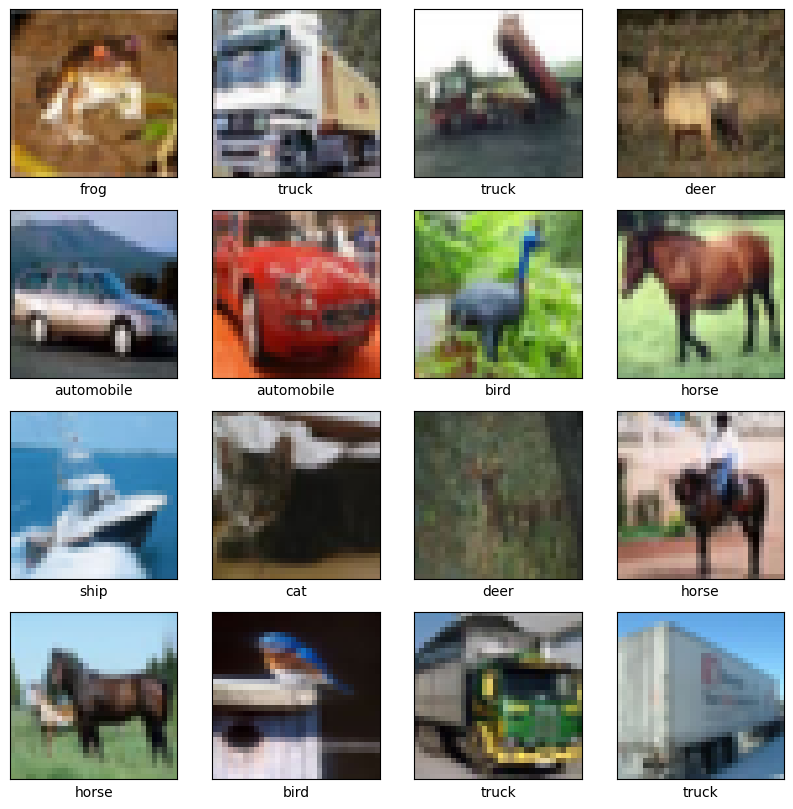

In [ ]:
# Define the classesin the CIFAR Dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

Build CNN Model

In [ ]:
model = models.Sequential()
# model.add(layers.Conv2D(25, (3, 3), activation='relu', input_shape=(32, 32, 3))) # 1 is from input data cant control
model.add(layers.Conv2D(25, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))# Input layer with 3x3 kernel and relu activation function
model.add(layers.MaxPooling2D((2, 2)))# 1st Max pooling layer with a downsampling rate of 4
model.add(layers.Conv2D(50, (3, 3), activation='relu'))# 1st Convulation layer with 50 filters(kernels) 3x3
model.add(layers.Conv2D(50, (3, 3), activation='relu'))# 2nd Convulation layer with 50 filters(kernels) 3x3
model.add(layers.MaxPooling2D((2, 2)))# 2nd Max pooling layer witha 2x2 kernel
model.add(layers.MaxPooling2D((2, 2)))# 3rd Max pooling layer witha 2x2 kernel
model.add(layers.Flatten())#Hidden layer
model.add(layers.Dense(100, activation='relu'))# 1st Hidden layer
model.add(layers.Dense(150, activation='relu'))# 2nd Hidden layer
model.add(layers.Dense(10))#Output layer with 10 output nodes
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 25)     │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 50)     │        11,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 450)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        15,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,310 (376.21 KB)

 Trainable params: 96,310 (376.21 KB)

 Non-trainable params: 0 (0.00 B)

Train model

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 69ms/step - accuracy: 0.3708 - loss: 1.7049 - val_accuracy: 0.5546 - val_loss: 1.2425
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.5822 - loss: 1.1694 - val_accuracy: 0.6519 - val_loss: 1.0029
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 68ms/step - accuracy: 0.6598 - loss: 0.9714 - val_accuracy: 0.6758 - val_loss: 0.9275
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 68ms/step - accuracy: 0.7000 - loss: 0.8574 - val_accuracy: 0.6853 - val_loss: 0.9125
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.7286 - loss: 0.7782 - val_accuracy: 0.7041 - val_loss: 0.8510
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 113s 73ms/step - accuracy: 0.7508 - loss: 0.7119 - val_accuracy: 0.7200 - val_loss: 0.8138
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 68ms/step - accuracy: 0.7660 - loss: 0.6596 - val_accuracy: 0.7188 - val_loss: 0.8351
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 

evaluate model

313/313 - 6s - 18ms/step - accuracy: 0.7247 - loss: 0.8472
0.7246999740600586


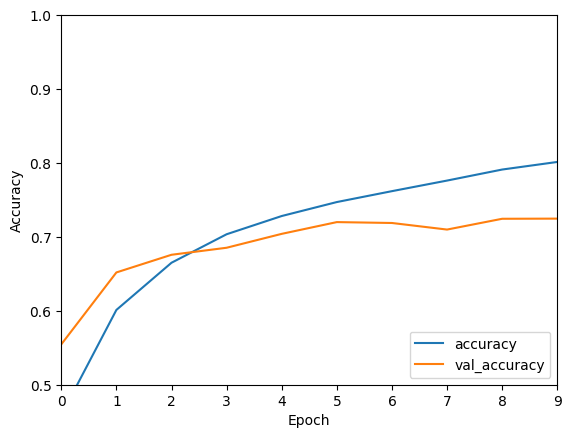

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xlim([0, 9])
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)

In [ ]:
# calculate training accuracy from the history object
train_acc = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_acc}")

Training Accuracy: 0.801360011100769


In [ ]:
# calculate testing accuracy from the history object
test_acc = history.history['accuracy'][-1]
print(f"Testing Accuracy: {test_acc}")

Testing Accuracy: 0.801360011100769


            **Structure of the CNN Model**
This CNN Model has  the follwing architecture
1. One input layer with padding (same), a 3x3 kernel and relu activation function  
2. Three Max pooling layers with a 2x2 kernel each
3. Two Convulation layers with a 3x3 kernel each
4. Three hidden layers ( 2 Denselayers  with 100 and 150 neurons repectively and 1 Faltten layer)
5. One output layer (with 10 neurons) where "from_logits=true", meaning Tensorflow will apply the correct activation( sigmoid or softmax) inside the function.

                 **Intrepretation of Results**
            
           ** a.Validation Accuracy and Loss**
The goal here is to asses how well the model has learned from the training data and how well it is able to generalize unseen data. A validation accuracy of 71.04% shows that the model correctly predicts 7 outof 10 samples. This indicates that the model is learning patterns but not perfectly. Additonally an 85.51% loss is an andication that the model is is not higly confident in its predictions. There could be several reasons for such a low performance, including  undefitting, imbalanced data set etc.

             ** b.Testing and Training Accuracy**
Both training and testing accuracy are at 80%. The model could be intrepreted as learnign well, however the model could be too simple with factors such as insufficient training time or poor learning rate playing a role.

**In conclusion**, we can increase the perfomance of our model. There are several apporaches to this; we can oncrease the complexity of our model, such as the number of convulation, pooling  and hidden layers. We can also tune hyper parameters or increase the trainign time.